In [1]:
# ============================================================
# STEP 1 — DATA LOADING & INSPECTION
# ============================================================

import pandas as pd
import numpy as np

# ── 1.1  Load the dataset ────────────────────────────────────
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")   # change filename as needed

# ── 1.2  Basic shape & structure ────────────────────────────
print("Shape:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

# ── 1.3  First look at the data ──────────────────────────────
print("\nFirst 5 rows:")
df.head()

Shape: (2640, 12)

Column names:
 ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

Data types:
 Year                      int64
Month                     int64
Region                   object
Model                    object
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type              object
Charging_Stations         int64
dtype: object

First 5 rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [2]:
# ── 1.6  Check for duplicates ────────────────────────────────
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")

# ── 1.7  Unique values in categorical columns ────────────────
cat_cols = ["Region", "Model", "Source_Type"]
for col in cat_cols:
    print(f"\n{col} ({df[col].nunique()} unique):", df[col].unique())

Duplicate rows: 0

Region (4 unique): ['Europe' 'Asia' 'North America' 'Middle East']

Model (5 unique): ['Model S' 'Model X' 'Model 3' 'Model Y' 'Cybertruck']

Source_Type (3 unique): ['Interpolated (Month)' 'Official (Quarter)' 'Estimated (Region)']


In [3]:
# ── 1.8  Numeric column ranges (sanity check) ────────────────
num_cols = ["Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
            "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"]

for col in num_cols:
    print(f"{col}: min={df[col].min()}, max={df[col].max()}, mean={df[col].mean():.2f}")

Estimated_Deliveries: min=48, max=25704, mean=9922.20
Production_Units: min=50, max=28939, mean=10655.85
Avg_Price_USD: min=50003.7, max=119965.36, mean=84907.34
Battery_Capacity_kWh: min=60, max=120, mean=87.06
Range_km: min=330, max=719, mean=500.26
CO2_Saved_tons: min=3.07, max=2548.55, mean=744.08
Charging_Stations: min=3002, max=14996, mean=8932.13


In [4]:
# ── 1.9  Year & Month coverage ───────────────────────────────
print("Year range:", df["Year"].min(), "→", df["Year"].max())
print("Months present:", sorted(df["Month"].unique()))
print("Total year-month combinations:", df.groupby(["Year","Month"]).ngroups)

Year range: 2015 → 2025
Months present: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]
Total year-month combinations: 132


In [5]:
# ============================================================
# STEP 2 — PREPROCESSING
# ============================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 2.1  Create datetime column from Year + Month ────────────
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(day=1))
df = df.sort_values("Date").reset_index(drop=True)

print("Date range:", df["Date"].min(), "→", df["Date"].max())

Date range: 2015-01-01 00:00:00 → 2025-12-01 00:00:00


In [6]:
# ── 2.2  Encode categorical columns ──────────────────────────

# Label encode Region and Model (no natural order)
le = LabelEncoder()
df["Region_enc"]   = le.fit_transform(df["Region"])
df["Model_enc"]    = le.fit_transform(df["Model"])

# Print mappings so you know what each number means
for col in ["Region", "Model"]:
    enc_col = col + "_enc"
    mapping = dict(zip(df[col], df[enc_col]))
    print(f"{col} encoding: {mapping}")

Region encoding: {'Asia': 0, 'Middle East': 2, 'North America': 3, 'Europe': 1}
Model encoding: {'Model Y': 4, 'Model 3': 1, 'Cybertruck': 0, 'Model S': 2, 'Model X': 3}


In [7]:
# ── 2.3  Ordinal encode Source_Type (quality order) ──────────
source_order = {
    "Official (Quarter)":    2,   # most reliable
    "Estimated (Region)":    1,
    "Interpolated (Month)":  0    # least reliable
}
df["Source_Type_enc"] = df["Source_Type"].map(source_order)
print("Source_Type encoding:", source_order)

Source_Type encoding: {'Official (Quarter)': 2, 'Estimated (Region)': 1, 'Interpolated (Month)': 0}


In [8]:
# ── 2.5  Scale numeric features ──────────────────────────────
scale_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"
]

scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaled columns — mean should be ~0, std ~1:")
print(df_scaled[scale_cols].describe().loc[["mean","std"]].round(3))

Scaled columns — mean should be ~0, std ~1:
      Estimated_Deliveries  Production_Units  Avg_Price_USD  \
mean                   0.0              -0.0           -0.0   
std                    1.0               1.0            1.0   

      Battery_Capacity_kWh  Range_km  CO2_Saved_tons  Charging_Stations  
mean                  -0.0       0.0             0.0               -0.0  
std                    1.0       1.0             1.0                1.0  


In [9]:
# ── 2.6  Final cleaned dataframe summary ─────────────────────
print("\nFinal columns:", df.columns.tolist())
print("Shape:", df.shape)

# Keep two versions:
# df        → original values + new encoded/date columns (use for EDA & feature engineering)
# df_scaled → standardized numerics (use for ML models)
df.head(3)


Final columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Region_enc', 'Model_enc', 'Source_Type_enc']
Shape: (2640, 16)


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Region_enc,Model_enc,Source_Type_enc
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,0,4,2
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,2,1,1
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,2,0,0


In [10]:
# ============================================================
# STEP 3 — EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

C:\Users\vaibh\AppData\Local\Temp\ipykernel_38832\2690600894.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[0], palette="Set2")
C:\Users\vaibh\AppData\Local\Temp\ipykernel_38832\2690600894.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[1], palette="Set2")


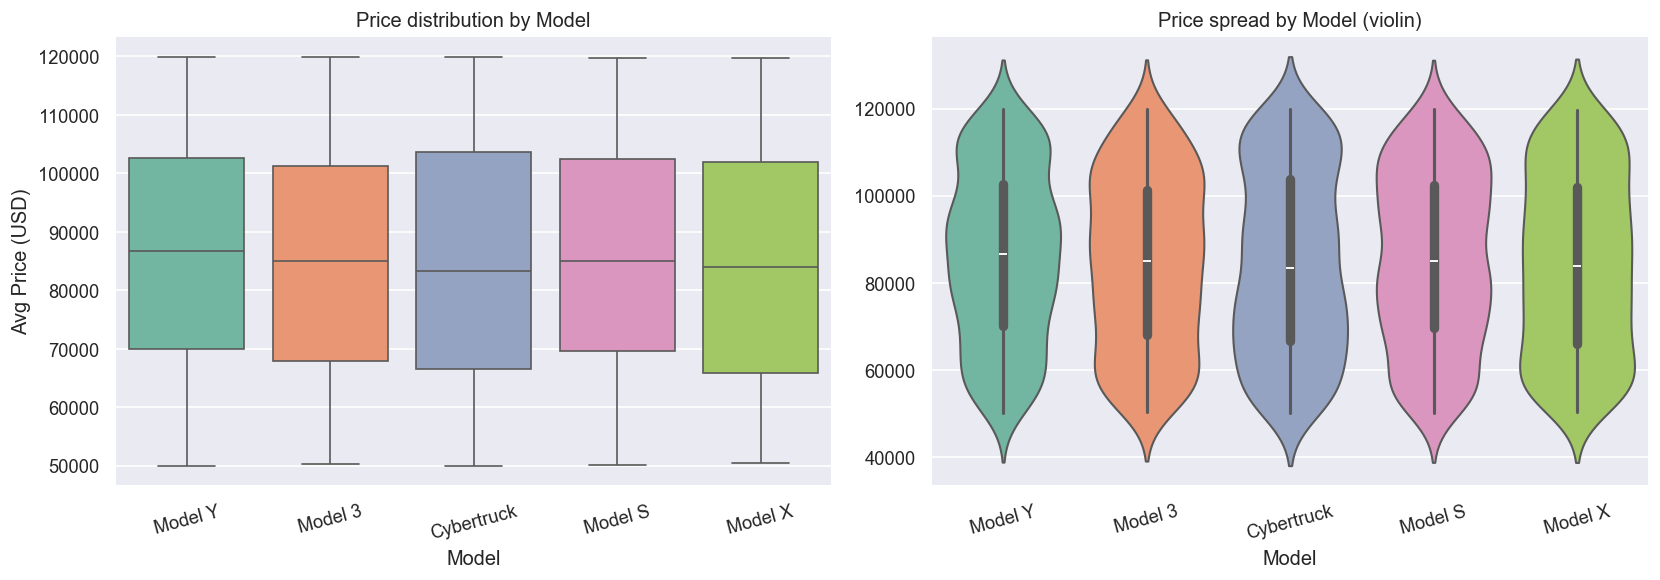

In [11]:
# ── 3.1  Price distribution by Model ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
sns.boxplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[0], palette="Set2")
axes[0].set_title("Price distribution by Model")
axes[0].set_ylabel("Avg Price (USD)")
axes[0].tick_params(axis='x', rotation=15)

# Violin plot
sns.violinplot(data=df, x="Model", y="Avg_Price_USD", ax=axes[1], palette="Set2")
axes[1].set_title("Price spread by Model (violin)")
axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

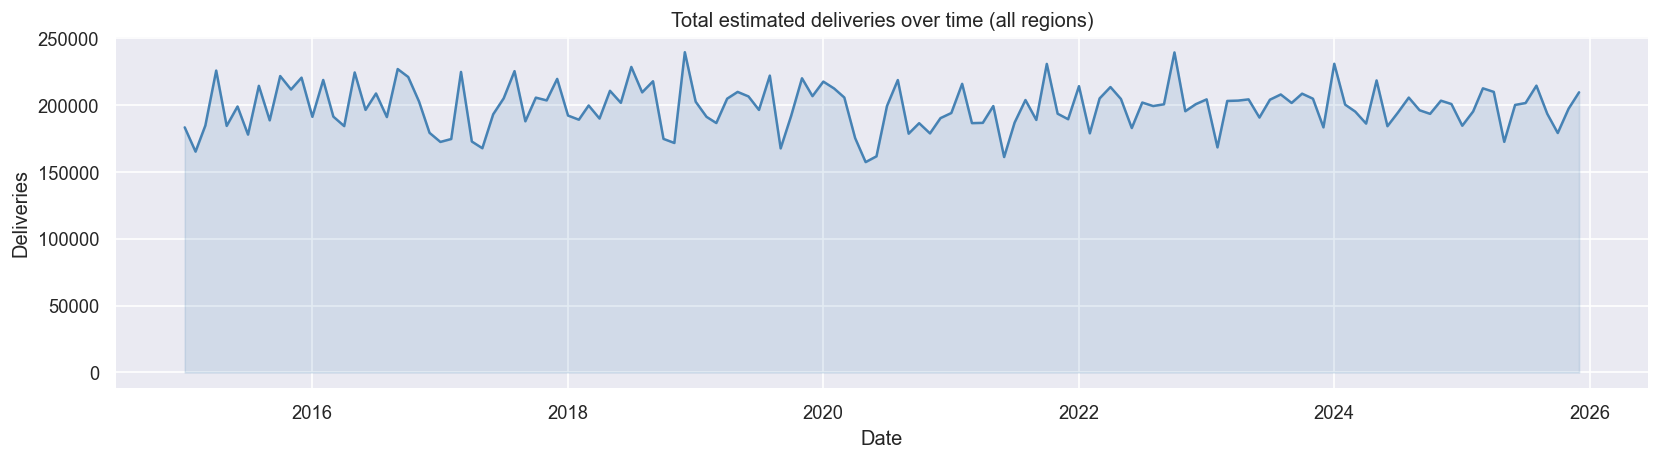

In [12]:
# ── 3.2  Monthly delivery trend (all regions combined) ────────
monthly = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(14, 4))
plt.plot(monthly["Date"], monthly["Estimated_Deliveries"], color="steelblue", linewidth=1.5)
plt.fill_between(monthly["Date"], monthly["Estimated_Deliveries"], alpha=0.15, color="steelblue")
plt.title("Total estimated deliveries over time (all regions)")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.tight_layout()
plt.show()

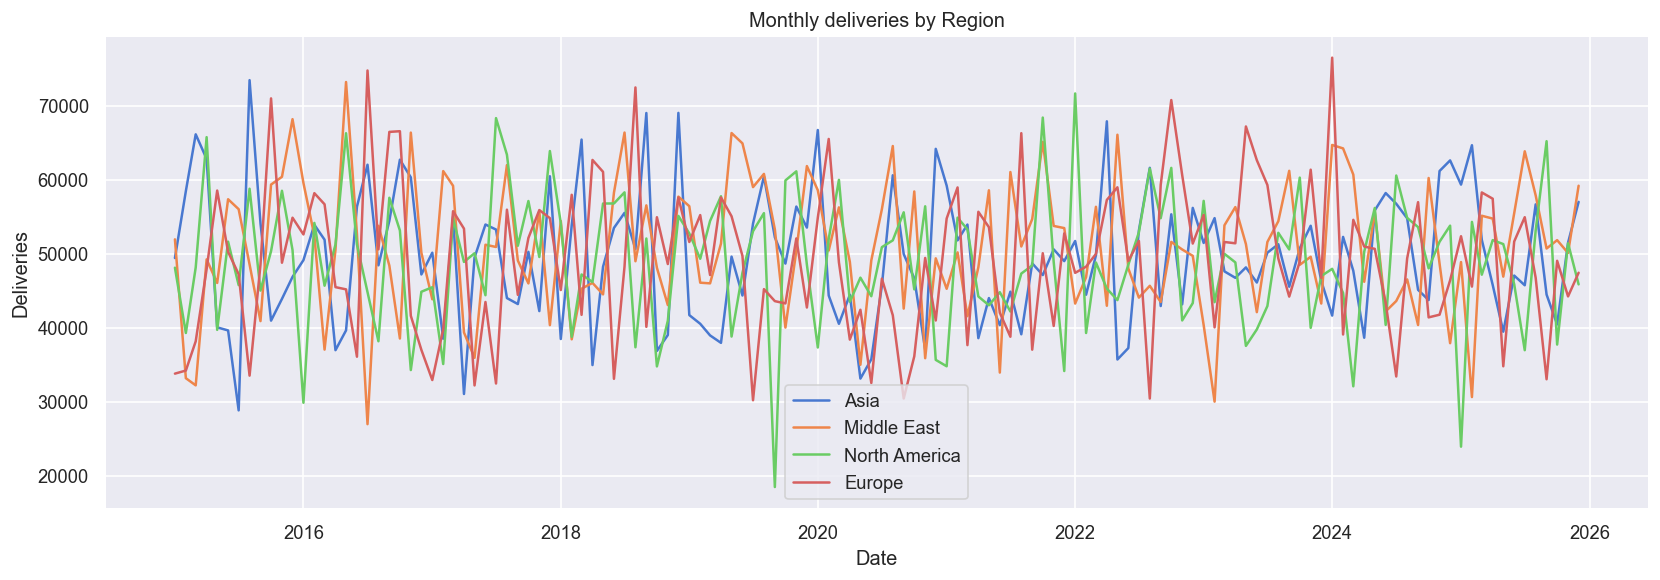

In [13]:
# ── 3.3  Deliveries by Region over time ──────────────────────
region_monthly = df.groupby(["Date", "Region"])["Estimated_Deliveries"].sum().reset_index()

plt.figure(figsize=(14, 5))
for region in df["Region"].unique():
    subset = region_monthly[region_monthly["Region"] == region]
    plt.plot(subset["Date"], subset["Estimated_Deliveries"], label=region, linewidth=1.5)

plt.title("Monthly deliveries by Region")
plt.xlabel("Date")
plt.ylabel("Deliveries")
plt.legend()
plt.tight_layout()
plt.show()

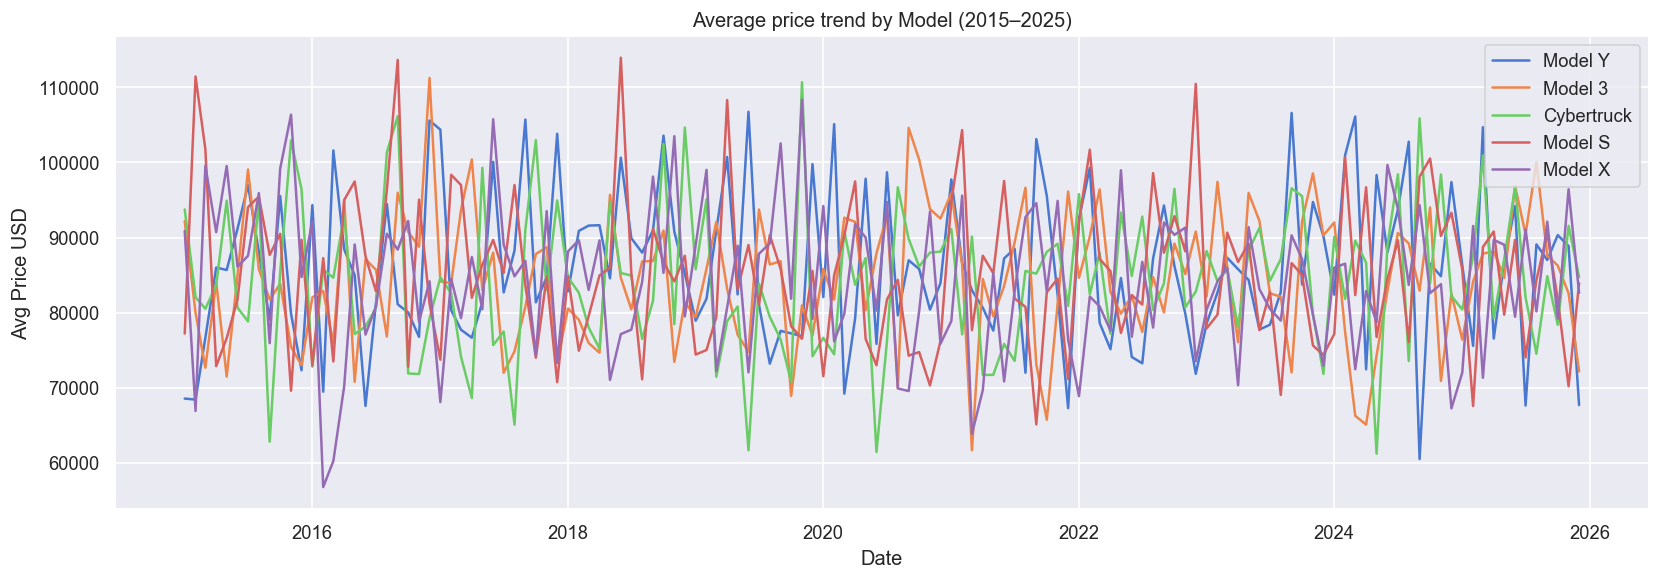

In [14]:
# ── 3.4  Avg Price trend over time by Model ───────────────────
price_monthly = df.groupby(["Date", "Model"])["Avg_Price_USD"].mean().reset_index()

plt.figure(figsize=(14, 5))
for model in df["Model"].unique():
    subset = price_monthly[price_monthly["Model"] == model]
    plt.plot(subset["Date"], subset["Avg_Price_USD"], label=model, linewidth=1.5)

plt.title("Average price trend by Model (2015–2025)")
plt.xlabel("Date")
plt.ylabel("Avg Price USD")
plt.legend()
plt.tight_layout()
plt.show()

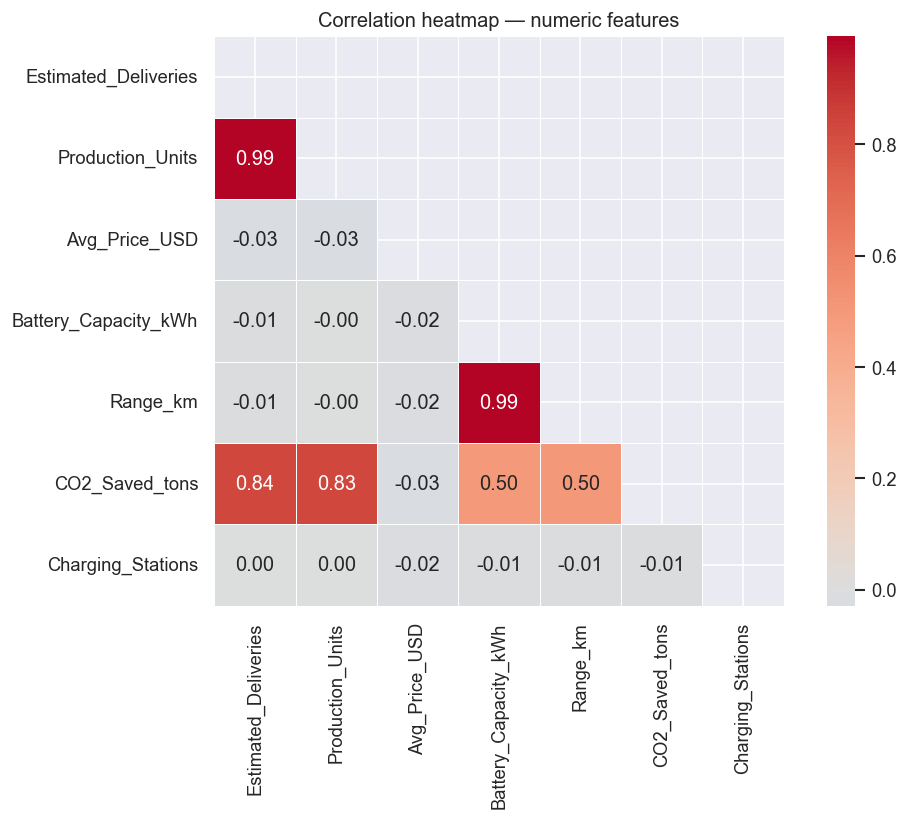

In [15]:
# ── 3.5  Correlation heatmap ──────────────────────────────────
num_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons", "Charging_Stations"
]

plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))   # show lower triangle only
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
plt.title("Correlation heatmap — numeric features")
plt.tight_layout()
plt.show()

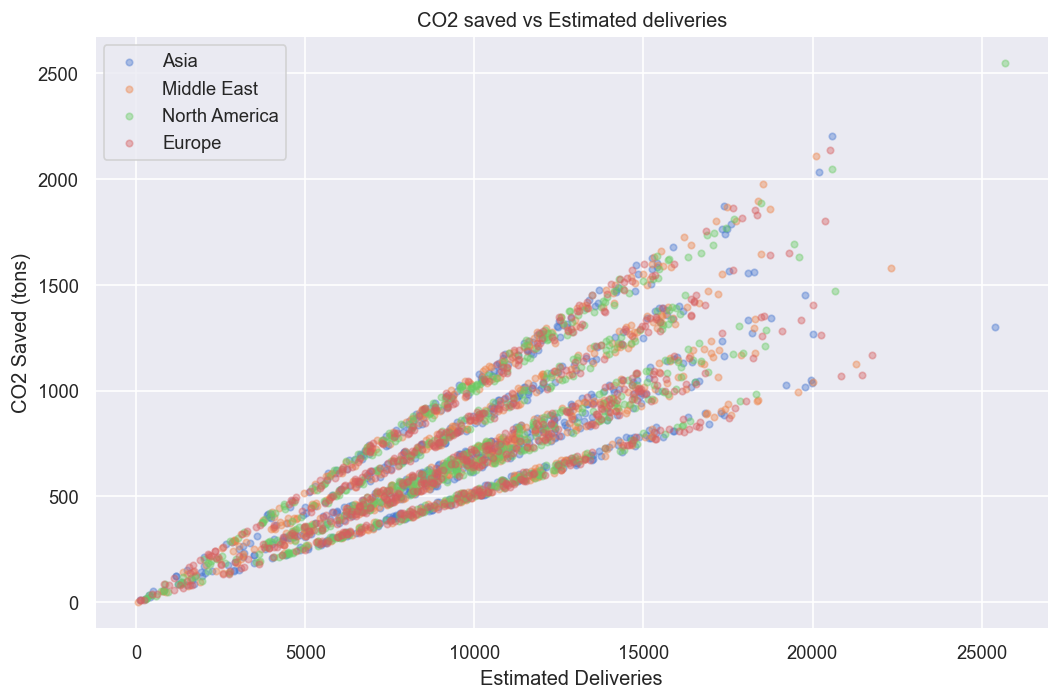

In [16]:
# ── 3.6  CO2 Saved vs Deliveries (colored by Region) ─────────
plt.figure(figsize=(9, 6))
for region in df["Region"].unique():
    subset = df[df["Region"] == region]
    plt.scatter(subset["Estimated_Deliveries"], subset["CO2_Saved_tons"],
                label=region, alpha=0.4, s=15)

plt.title("CO2 saved vs Estimated deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("CO2 Saved (tons)")
plt.legend()
plt.tight_layout()
plt.show()

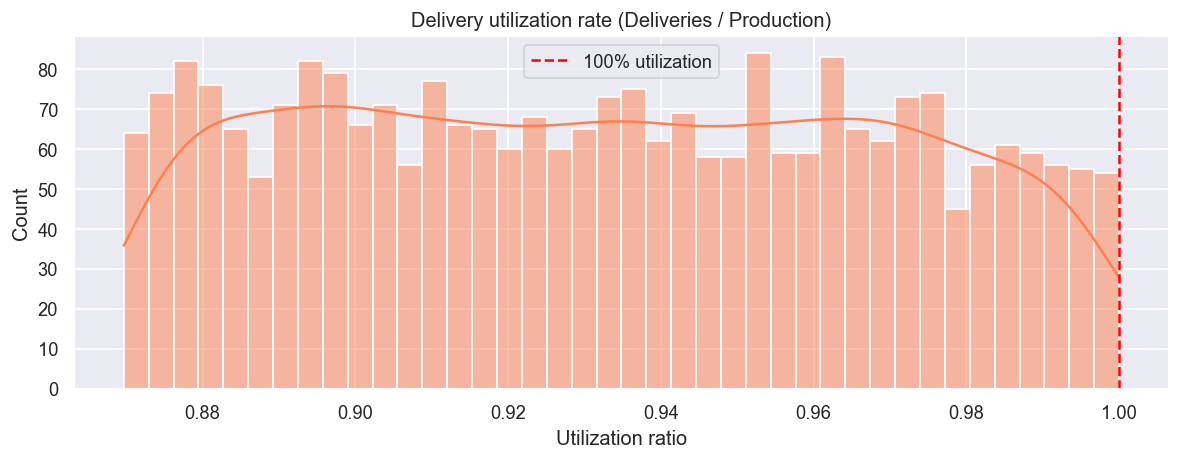

Mean utilization: 0.933
Rows > 100% utilization: 0


In [17]:
# ── 3.7  Deliveries vs Production gap (utilization check) ────
df["Utilization"] = df["Estimated_Deliveries"] / df["Production_Units"]

plt.figure(figsize=(10, 4))
sns.histplot(df["Utilization"], bins=40, kde=True, color="coral")
plt.axvline(1.0, color="red", linestyle="--", label="100% utilization")
plt.title("Delivery utilization rate (Deliveries / Production)")
plt.xlabel("Utilization ratio")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean utilization: {df['Utilization'].mean():.3f}")
print(f"Rows > 100% utilization: {(df['Utilization'] > 1).sum()}")

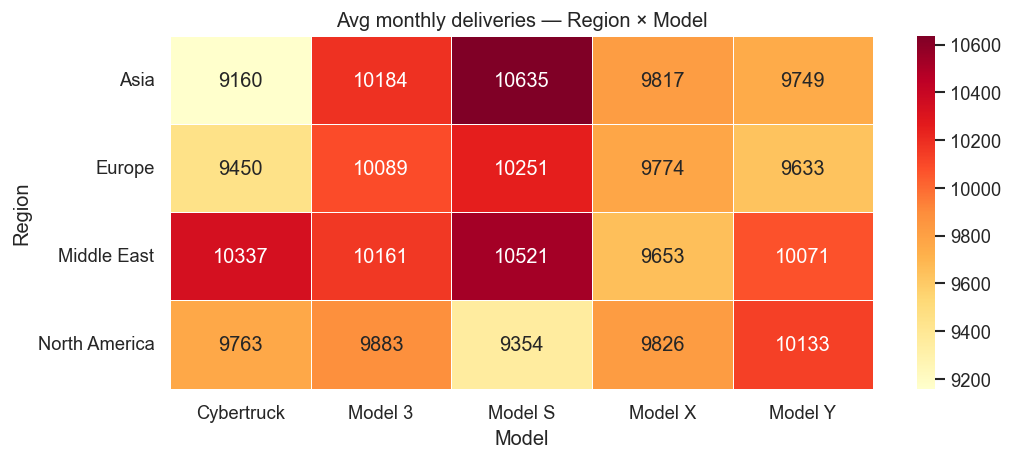

In [18]:
# ── 3.8  Heatmap — avg deliveries by Region × Model ──────────
pivot = df.pivot_table(
    values="Estimated_Deliveries",
    index="Region",
    columns="Model",
    aggfunc="mean"
).round(0)

plt.figure(figsize=(9, 4))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd", linewidths=0.5)
plt.title("Avg monthly deliveries — Region × Model")
plt.tight_layout()
plt.show()

In [19]:
# ── 4.1  Ratio features ───────────────────────────────────────
df["Price_per_kWh"]       = df["Avg_Price_USD"] / df["Battery_Capacity_kWh"]
df["CO2_per_Delivery"]    = df["CO2_Saved_tons"] / df["Estimated_Deliveries"]
df["Range_per_kWh"]       = df["Range_km"] / df["Battery_Capacity_kWh"]
df["Charging_per_1k_Del"] = df["Charging_Stations"] / (df["Estimated_Deliveries"] / 1000)



print("New ratio features sample:")
df[["Price_per_kWh","CO2_per_Delivery","Range_per_kWh","Charging_per_1k_Del","Utilization"]].describe().round(3)

New ratio features sample:


,Price_per_kWh,CO2_per_Delivery,Range_per_kWh,Charging_per_1k_Del,Utilization
count,2640.000,2640.000,2640.000,2640.000,2640.000
mean,1033.348,0.075,5.745,1476.181,0.933
std,353.256,0.018,0.145,6145.977,0.037
min,417.085,0.049,5.493,162.416,0.870
25%,759.219,0.063,5.617,597.302,0.900
50%,978.022,0.071,5.750,899.498,0.932
75%,1261.052,0.088,5.867,1347.599,0.964
max,1999.423,0.108,5.992,230625.000,1.000


In [20]:
# ── 4.2  Time / seasonality features ─────────────────────────
df["Quarter"]      = df["Date"].dt.quarter
df["Month_sin"]    = np.sin(2 * np.pi * df["Month"] / 12)   # cyclical encoding
df["Month_cos"]    = np.cos(2 * np.pi * df["Month"] / 12)
df["Year_norm"]    = (df["Year"] - df["Year"].min()) / (df["Year"].max() - df["Year"].min())
df["Is_Q_end"]     = df["Month"].isin([3, 6, 9, 12]).astype(int)  # quarter-end spike flag

print("Time features added:")
df[["Month","Quarter","Month_sin","Month_cos","Year_norm","Is_Q_end"]].head(6)

Time features added:


,Month,Quarter,Month_sin,Month_cos,Year_norm,Is_Q_end
0,1,1,0.5,0.866025,0.0,0
1,1,1,0.5,0.866025,0.0,0
2,1,1,0.5,0.866025,0.0,0
3,1,1,0.5,0.866025,0.0,0
4,1,1,0.5,0.866025,0.0,0
5,1,1,0.5,0.866025,0.0,0


In [21]:
# ── 4.3  Lag features (per Region+Model group) ────────────────
# Sort to ensure correct order before lagging
df = df.sort_values(["Region","Model","Date"]).reset_index(drop=True)

grp = df.groupby(["Region","Model"])

df["Deliveries_lag1"]  = grp["Estimated_Deliveries"].shift(1)
df["Deliveries_lag3"]  = grp["Estimated_Deliveries"].shift(3)
df["Price_lag1"]       = grp["Avg_Price_USD"].shift(1)
df["Price_lag3"]       = grp["Avg_Price_USD"].shift(3)

print("Lag features (NaN in first rows is expected):")
df[["Region","Model","Date","Estimated_Deliveries","Deliveries_lag1","Deliveries_lag3"]].head(8)

Lag features (NaN in first rows is expected):


,Region,Model,Date,Estimated_Deliveries,Deliveries_lag1,Deliveries_lag3
0,Asia,Cybertruck,2015-01-01,11325,NaN,NaN
1,Asia,Cybertruck,2015-02-01,13254,11325.0,NaN
2,Asia,Cybertruck,2015-03-01,10257,13254.0,NaN
3,Asia,Cybertruck,2015-04-01,15221,10257.0,11325.0
4,Asia,Cybertruck,2015-05-01,6406,15221.0,13254.0
5,Asia,Cybertruck,2015-06-01,7201,6406.0,10257.0
6,Asia,Cybertruck,2015-07-01,113,7201.0,15221.0
7,Asia,Cybertruck,2015-08-01,10222,113.0,6406.0


In [22]:
# ── 4.4  Rolling average features ────────────────────────────
df["Deliveries_roll3"]  = grp["Estimated_Deliveries"].transform(lambda x: x.shift(1).rolling(3).mean())
df["Deliveries_roll6"]  = grp["Estimated_Deliveries"].transform(lambda x: x.shift(1).rolling(6).mean())
df["Price_roll3"]       = grp["Avg_Price_USD"].transform(lambda x: x.shift(1).rolling(3).mean())

print("Rolling features sample:")
df[["Region","Model","Date","Estimated_Deliveries",
    "Deliveries_roll3","Deliveries_roll6","Price_roll3"]].head(10)

Rolling features sample:


,Region,Model,Date,Estimated_Deliveries,Deliveries_roll3,Deliveries_roll6,Price_roll3
0,Asia,Cybertruck,2015-01-01,11325,NaN,NaN,NaN
1,Asia,Cybertruck,2015-02-01,13254,NaN,NaN,NaN
2,Asia,Cybertruck,2015-03-01,10257,NaN,NaN,NaN
3,Asia,Cybertruck,2015-04-01,15221,11612.000000,NaN,69473.536667
4,Asia,Cybertruck,2015-05-01,6406,12910.666667,NaN,88886.053333
5,Asia,Cybertruck,2015-06-01,7201,10628.000000,NaN,95123.903333
6,Asia,Cybertruck,2015-07-01,113,9609.333333,10610.666667,111575.103333
7,Asia,Cybertruck,2015-08-01,10222,4573.333333,8742.000000,112368.573333
8,Asia,Cybertruck,2015-09-01,10844,5845.333333,8236.666667,102486.100000
9,Asia,Cybertruck,2015-10-01,5675,7059.666667,8334.500000,84268.383333


In [23]:
# ── 4.5  Region-level aggregate features ─────────────────────
region_stats = df.groupby(["Region","Date"]).agg(
    Region_Total_Deliveries = ("Estimated_Deliveries","sum"),
    Region_Avg_Price        = ("Avg_Price_USD","mean"),
    Region_Avg_CO2          = ("CO2_Saved_tons","mean")
).reset_index()

df = df.merge(region_stats, on=["Region","Date"], how="left")

print("Region aggregate features added:")
df[["Region","Date","Estimated_Deliveries","Region_Total_Deliveries","Region_Avg_Price"]].head(6)

Region aggregate features added:


,Region,Date,Estimated_Deliveries,Region_Total_Deliveries,Region_Avg_Price
0,Asia,2015-01-01,11325,49395,74739.534
1,Asia,2015-02-01,13254,58433,82105.972
2,Asia,2015-03-01,10257,66112,74972.820
3,Asia,2015-04-01,15221,62791,108675.948
4,Asia,2015-05-01,6406,40028,82724.496
5,Asia,2015-06-01,7201,39613,76485.648


In [26]:
# ── 4.6  Model-level market share per region ──────────────────
df["Model_Market_Share"] = (
    df["Estimated_Deliveries"] / df["Region_Total_Deliveries"]
)

print("Market share range:", round(df["Model_Market_Share"].min(), 3),
      "→", round(df["Model_Market_Share"].max(), 3))

Market share range: 0.001 → 0.488


In [27]:
# ── 4.7  Drop rows with NaN from lag/rolling (first few months per group)
df_model = df.dropna(subset=["Deliveries_lag1","Deliveries_roll6","Price_lag1"]).reset_index(drop=True)

print(f"Rows before dropping NaN lag rows: {len(df)}")
print(f"Rows after  dropping NaN lag rows: {len(df_model)}")
print(f"\nFinal feature set — {df_model.shape[1]} columns:")
print(df_model.columns.tolist())

Rows before dropping NaN lag rows: 2640
Rows after  dropping NaN lag rows: 2520

Final feature set — 37 columns:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Region_enc', 'Model_enc', 'Source_Type_enc', 'Utilization', 'Price_per_kWh', 'CO2_per_Delivery', 'Range_per_kWh', 'Charging_per_1k_Del', 'Quarter', 'Month_sin', 'Month_cos', 'Year_norm', 'Is_Q_end', 'Deliveries_lag1', 'Deliveries_lag3', 'Price_lag1', 'Price_lag3', 'Deliveries_roll3', 'Deliveries_roll6', 'Price_roll3', 'Region_Total_Deliveries', 'Region_Avg_Price', 'Region_Avg_CO2', 'Model_Market_Share']


In [28]:
# ── 4.8  Feature summary ──────────────────────────────────────
feature_cols = [
    # Original
    "Battery_Capacity_kWh","Range_km","Charging_Stations","Source_Type_enc",
    "Region_enc","Model_enc",
    # Ratio
    "Price_per_kWh","CO2_per_Delivery","Range_per_kWh",
    "Charging_per_1k_Del","Utilization",
    # Time
    "Year_norm","Month_sin","Month_cos","Quarter","Is_Q_end",
    # Lag
    "Deliveries_lag1","Deliveries_lag3","Price_lag1","Price_lag3",
    # Rolling
    "Deliveries_roll3","Deliveries_roll6","Price_roll3",
    # Region aggregates
    "Region_Total_Deliveries","Region_Avg_Price","Model_Market_Share"
]

print(f"Total features for modeling: {len(feature_cols)}")
print(df_model[feature_cols].describe().round(2))

Total features for modeling: 26
       Battery_Capacity_kWh  Range_km  Charging_Stations  Source_Type_enc  \
count               2520.00   2520.00            2520.00          2520.00   
mean                  86.98    499.76            8913.62             1.00   
std                   20.87    121.03            3472.03             0.82   
min                   60.00    330.00            3002.00             0.00   
25%                   75.00    418.00            5872.00             0.00   
50%                   82.00    470.00            8869.00             1.00   
75%                  100.00    586.00           11910.75             2.00   
max                  120.00    719.00           14996.00             2.00   

       Region_enc  Model_enc  Price_per_kWh  CO2_per_Delivery  Range_per_kWh  \
count     2520.00    2520.00        2520.00           2520.00        2520.00   
mean         1.50       2.00        1034.45              0.07           5.74   
std          1.12       1.41      

In [30]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 5.2 MB/s eta 0:00:20
    --------------------------------------- 1.8/101.7 MB 5.8 MB/s eta 0:00:18
   - -------------------------------------- 3.4/101.7 MB 6.5 MB/s eta 0:00:16
   - -------------------------------------- 3.7/101.7 MB 5.8 MB/s eta 0:00:17
   - -------------------------------------- 4.2/101.7 MB 4.5 MB/s eta 0:00:22
   -- ------------------------------------- 5.5/101.7 MB 4.8 MB/s eta 0:00:21
   -- ------------------------------------- 6.6/101.7 MB 4.9 MB/s eta 0:00:20
   --- ------------------------------------ 7.9/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 8.7/101.7 MB 5.1 MB/s eta 0:00:19
   --- ------------------------------------ 9.4/101.7 MB 4.8 MB/s eta 0:00:20
   ---- ----------------------------------- 10.5/101.7 MB 4.9 MB/s eta 0:00:19
   ---- ----------------------------------- 11.8/101.7 MB 5.0 MB/s et

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [32]:
# ── 5.1  Define features and targets ─────────────────────────
feature_cols = [
    "Battery_Capacity_kWh", "Range_km", "Charging_Stations", "Source_Type_enc",
    "Region_enc", "Model_enc",
    "Price_per_kWh", "CO2_per_Delivery", "Range_per_kWh",
    "Charging_per_1k_Del", "Utilization",
    "Year_norm", "Month_sin", "Month_cos", "Quarter", "Is_Q_end",
    "Deliveries_lag1", "Deliveries_lag3", "Price_lag1", "Price_lag3",
    "Deliveries_roll3", "Deliveries_roll6", "Price_roll3",
    "Region_Total_Deliveries", "Region_Avg_Price", "Model_Market_Share"
]

X = df_model[feature_cols]
y_price     = df_model["Avg_Price_USD"]
y_delivery  = df_model["Estimated_Deliveries"]

# Time-aware split — use last 20% of time as test (don't shuffle!)
split_idx = int(len(df_model) * 0.8)
X_train, X_test         = X.iloc[:split_idx], X.iloc[split_idx:]
y_price_train, y_price_test         = y_price.iloc[:split_idx], y_price.iloc[split_idx:]
y_delivery_train, y_delivery_test   = y_delivery.iloc[:split_idx], y_delivery.iloc[split_idx:]

print(f"Train size: {len(X_train)}  |  Test size: {len(X_test)}")

Train size: 2016  |  Test size: 504


In [33]:
# ── 5.2  Evaluation helper ────────────────────────────────────
def evaluate(name, y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"  {name:<22} MAE={mae:>10.2f}  RMSE={rmse:>10.2f}  R²={r2:.4f}  MAPE={mape:.2f}%")
    return {"Model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}

In [34]:
# ── 5.3  Train & evaluate — TARGET: Avg_Price_USD ─────────────
print("=" * 70)
print("TARGET: Avg_Price_USD")
print("=" * 70)

price_results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_price_train)
price_results.append(evaluate("Linear Regression", y_price_test, lr.predict(X_test)))

# Random Forest
rf_price = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_price.fit(X_train, y_price_train)
price_results.append(evaluate("Random Forest", y_price_test, rf_price.predict(X_test)))

# XGBoost
xgb_price = XGBRegressor(n_estimators=200, learning_rate=0.05,
                          max_depth=6, random_state=42,
                          verbosity=0, n_jobs=-1)
xgb_price.fit(X_train, y_price_train,
              eval_set=[(X_test, y_price_test)], verbose=False)
price_results.append(evaluate("XGBoost", y_price_test, xgb_price.predict(X_test)))

price_df = pd.DataFrame(price_results).sort_values("R2", ascending=False)
print("\nBest model for price:", price_df.iloc[0]["Model"])

TARGET: Avg_Price_USD
  Linear Regression      MAE=   4720.91  RMSE=   5855.59  R²=0.9133  MAPE=5.78%
  Random Forest          MAE=    264.55  RMSE=    579.63  R²=0.9992  MAPE=0.34%
  XGBoost                MAE=    358.16  RMSE=    552.32  R²=0.9992  MAPE=0.46%

Best model for price: XGBoost


In [35]:
# ── 5.4  Train & evaluate — TARGET: Estimated_Deliveries ──────
print("=" * 70)
print("TARGET: Estimated_Deliveries")
print("=" * 70)

del_results = []

# Linear Regression
lr2 = LinearRegression()
lr2.fit(X_train, y_delivery_train)
del_results.append(evaluate("Linear Regression", y_delivery_test, lr2.predict(X_test)))

# Random Forest
rf_del = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_del.fit(X_train, y_delivery_train)
del_results.append(evaluate("Random Forest", y_delivery_test, rf_del.predict(X_test)))

# XGBoost
xgb_del = XGBRegressor(n_estimators=200, learning_rate=0.05,
                        max_depth=6, random_state=42,
                        verbosity=0, n_jobs=-1)
xgb_del.fit(X_train, y_delivery_train,
            eval_set=[(X_test, y_delivery_test)], verbose=False)
del_results.append(evaluate("XGBoost", y_delivery_test, xgb_del.predict(X_test)))

del_df = pd.DataFrame(del_results).sort_values("R2", ascending=False)
print("\nBest model for deliveries:", del_df.iloc[0]["Model"])

TARGET: Estimated_Deliveries
  Linear Regression      MAE=    440.38  RMSE=    734.19  R²=0.9644  MAPE=12.61%
  Random Forest          MAE=    160.94  RMSE=    486.89  R²=0.9843  MAPE=2.67%
  XGBoost                MAE=    151.96  RMSE=    447.64  R²=0.9868  MAPE=2.40%

Best model for deliveries: XGBoost


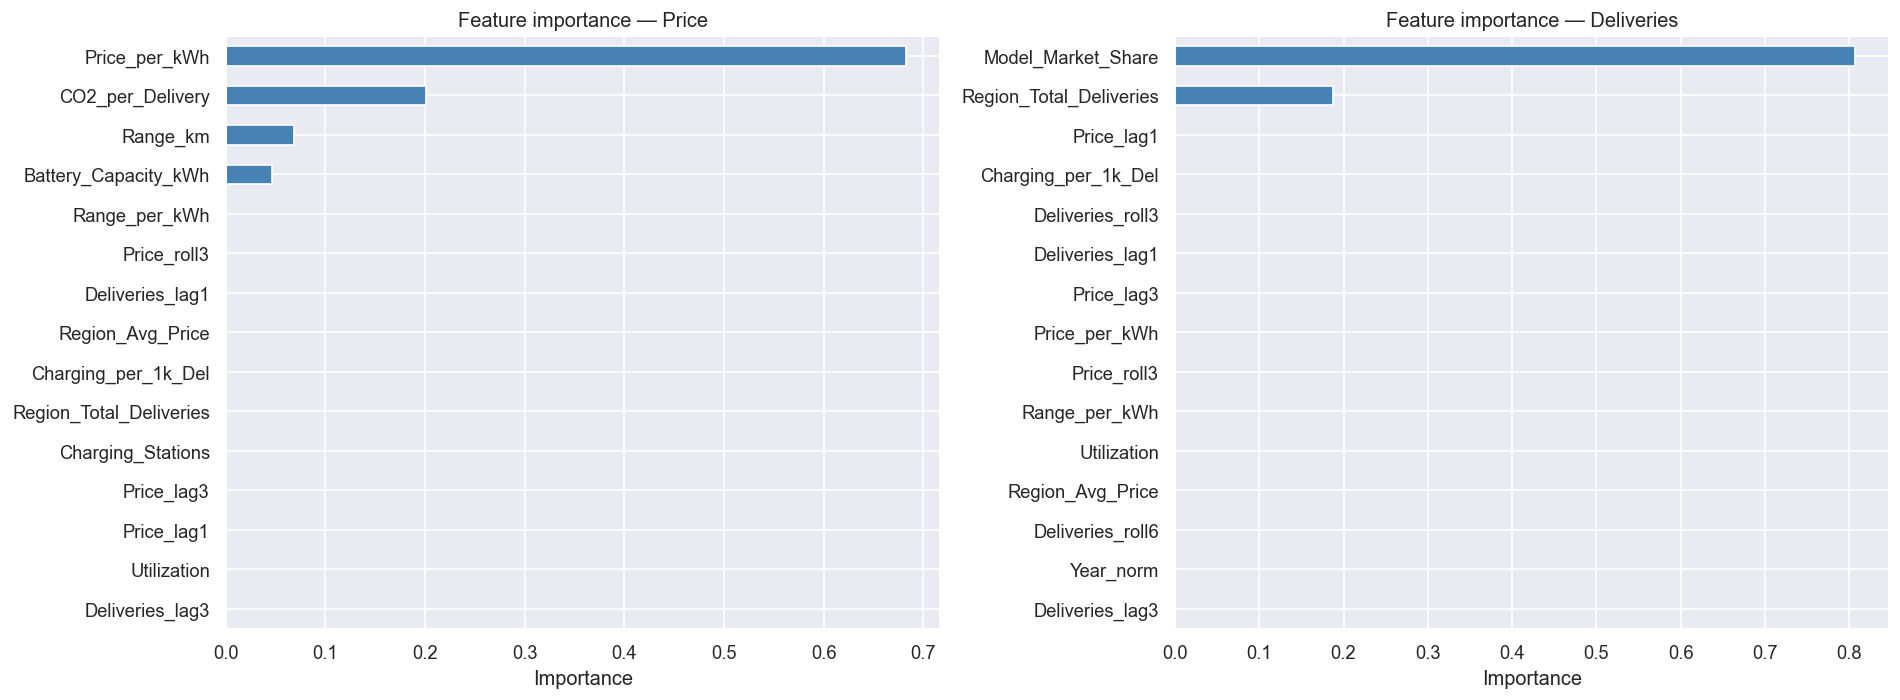

In [36]:
# ── 5.5  Feature importance (best model for each target) ──────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, model, title in zip(axes,
                             [rf_price, rf_del],
                             ["Feature importance — Price", "Feature importance — Deliveries"]):
    importances = pd.Series(model.feature_importances_, index=feature_cols)
    importances.sort_values().tail(15).plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [37]:
# ── 5.7  Summary table ────────────────────────────────────────
print("\n📊 PRICE MODEL COMPARISON")
print(price_df.to_string(index=False))

print("\n📊 DELIVERY MODEL COMPARISON")
print(del_df.to_string(index=False))


📊 PRICE MODEL COMPARISON
            Model         MAE        RMSE       R2     MAPE
          XGBoost  358.164914  552.316414 0.999228 0.457926
    Random Forest  264.547505  579.634340 0.999150 0.336726
Linear Regression 4720.908335 5855.588724 0.913277 5.778264

📊 DELIVERY MODEL COMPARISON
            Model        MAE       RMSE       R2      MAPE
          XGBoost 151.956161 447.643640 0.986766  2.402344
    Random Forest 160.936488 486.886642 0.984344  2.668525
Linear Regression 440.384320 734.186895 0.964401 12.609489


In [38]:
# ============================================================
# STEP 6 — HYPERPARAMETER TUNING (XGBoost)
# ============================================================

from sklearn.model_selection import RandomizedSearchCV, KFold
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings("ignore")

In [39]:
# ── 6.1  Define parameter search space ───────────────────────
param_dist = {
    "n_estimators":    randint(100, 500),
    "max_depth":       randint(3, 10),
    "learning_rate":   uniform(0.01, 0.2),
    "subsample":       uniform(0.6, 0.4),       # 0.6 → 1.0
    "colsample_bytree":uniform(0.6, 0.4),       # 0.6 → 1.0
    "min_child_weight":randint(1, 10),
    "gamma":           uniform(0, 0.5),
    "reg_alpha":       uniform(0, 1.0),         # L1
    "reg_lambda":      uniform(0.5, 2.0),       # L2
}

# Time-series safe CV — no shuffling, respect temporal order
tscv = KFold(n_splits=5, shuffle=False)

In [40]:
# ── 6.2  Tune for Avg_Price_USD ──────────────────────────────
print("Tuning XGBoost for Avg_Price_USD ...")

xgb_price_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)

search_price = RandomizedSearchCV(
    xgb_price_base,
    param_distributions=param_dist,
    n_iter=40,                  # increase to 80+ for more thorough search
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_price.fit(X_train, y_price_train)

print("\nBest params (Price):")
for k, v in search_price.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-search_price.best_score_:.2f}")

Tuning XGBoost for Avg_Price_USD ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params (Price):
  colsample_bytree: 0.9718790609370292
  gamma: 0.4040601897822085
  learning_rate: 0.1366807513020847
  max_depth: 8
  min_child_weight: 4
  n_estimators: 385
  reg_alpha: 0.8832802589188683
  reg_lambda: 1.148690042010548
  subsample: 0.6488351818802693
Best CV RMSE: 822.64


In [41]:
# ── 6.3  Tune for Estimated_Deliveries ───────────────────────
print("\nTuning XGBoost for Estimated_Deliveries ...")

xgb_del_base = XGBRegressor(random_state=42, verbosity=0, n_jobs=-1)

search_del = RandomizedSearchCV(
    xgb_del_base,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tscv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
search_del.fit(X_train, y_delivery_train)

print("\nBest params (Deliveries):")
for k, v in search_del.best_params_.items():
    print(f"  {k}: {v}")
print(f"Best CV RMSE: {-search_del.best_score_:.2f}")


Tuning XGBoost for Estimated_Deliveries ...
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best params (Deliveries):
  colsample_bytree: 0.9895022075365837
  gamma: 0.11638567021515211
  learning_rate: 0.02812128690656416
  max_depth: 8
  min_child_weight: 3
  n_estimators: 463
  reg_alpha: 0.5142344384136116
  reg_lambda: 1.684829137724085
  subsample: 0.6185801650879991
Best CV RMSE: 227.88


In [42]:
# ── 6.4  Evaluate tuned models on test set ───────────────────
print("=" * 65)
print("BEFORE vs AFTER TUNING — Avg_Price_USD")
print("=" * 65)

# Before (default XGBoost from Step 5)
evaluate("XGBoost (default)",  y_price_test, xgb_price.predict(X_test))
# After
best_price_pred = search_price.best_estimator_.predict(X_test)
evaluate("XGBoost (tuned)",    y_price_test, best_price_pred)

print("\n" + "=" * 65)
print("BEFORE vs AFTER TUNING — Estimated_Deliveries")
print("=" * 65)

evaluate("XGBoost (default)",  y_delivery_test, xgb_del.predict(X_test))
best_del_pred = search_del.best_estimator_.predict(X_test)
evaluate("XGBoost (tuned)",    y_delivery_test, best_del_pred)

BEFORE vs AFTER TUNING — Avg_Price_USD
  XGBoost (default)      MAE=    358.16  RMSE=    552.32  R²=0.9992  MAPE=0.46%
  XGBoost (tuned)        MAE=    471.64  RMSE=    651.61  R²=0.9989  MAPE=0.60%

BEFORE vs AFTER TUNING — Estimated_Deliveries
  XGBoost (default)      MAE=    151.96  RMSE=    447.64  R²=0.9868  MAPE=2.40%
  XGBoost (tuned)        MAE=    121.75  RMSE=    377.42  R²=0.9906  MAPE=1.98%


{'Model': 'XGBoost (tuned)',
 'MAE': 121.75192260742188,
 'RMSE': np.float64(377.4187205545056),
 'R2': 0.9905925393104553,
 'MAPE': np.float64(1.975550225863888)}

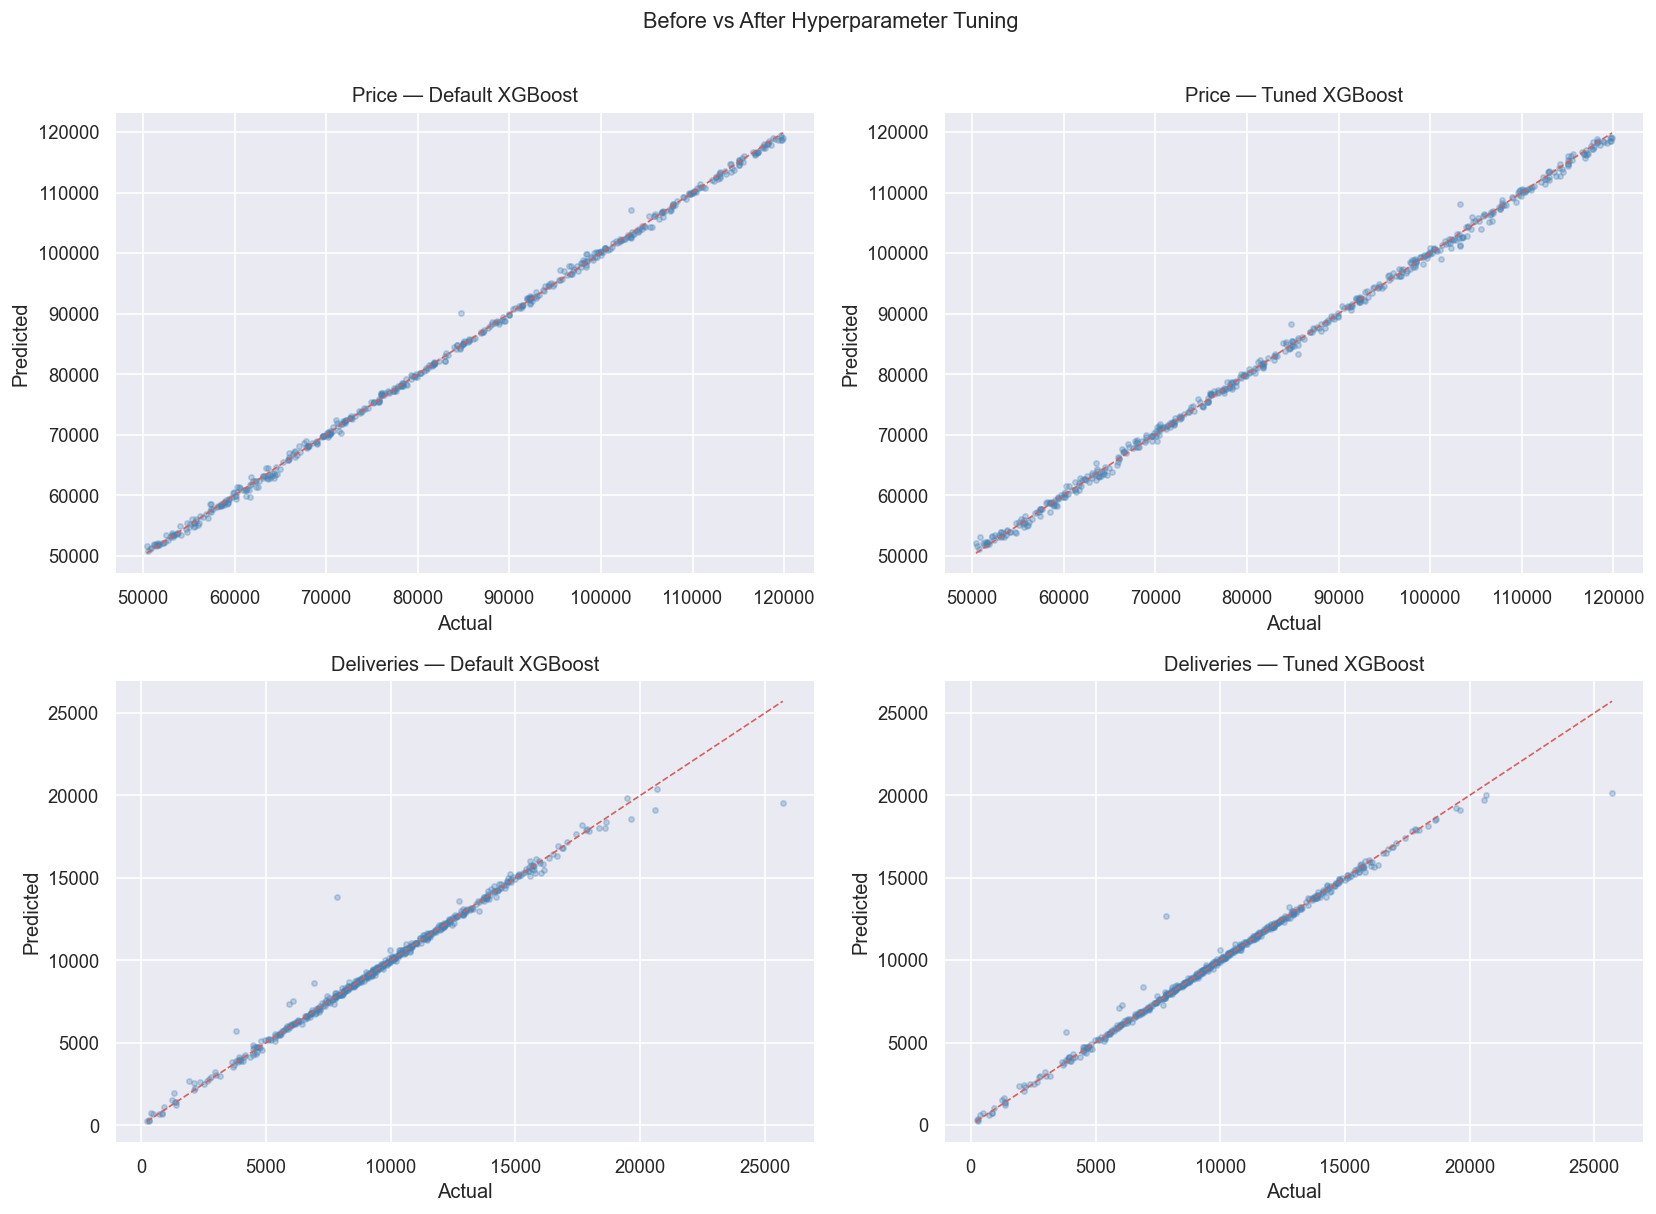

In [43]:
# ── 6.5  Visual: Before vs After (Actual vs Predicted) ────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

pairs = [
    (xgb_price.predict(X_test),       y_price_test,    "Price — Default XGBoost",   axes[0][0]),
    (best_price_pred,                  y_price_test,    "Price — Tuned XGBoost",     axes[0][1]),
    (xgb_del.predict(X_test),          y_delivery_test, "Deliveries — Default XGBoost", axes[1][0]),
    (best_del_pred,                    y_delivery_test, "Deliveries — Tuned XGBoost",   axes[1][1]),
]

for preds, y_true, title, ax in pairs:
    ax.scatter(y_true, preds, alpha=0.3, s=10, color="steelblue")
    lims = [min(y_true.min(), preds.min()), max(y_true.max(), preds.max())]
    ax.plot(lims, lims, "r--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.suptitle("Before vs After Hyperparameter Tuning", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

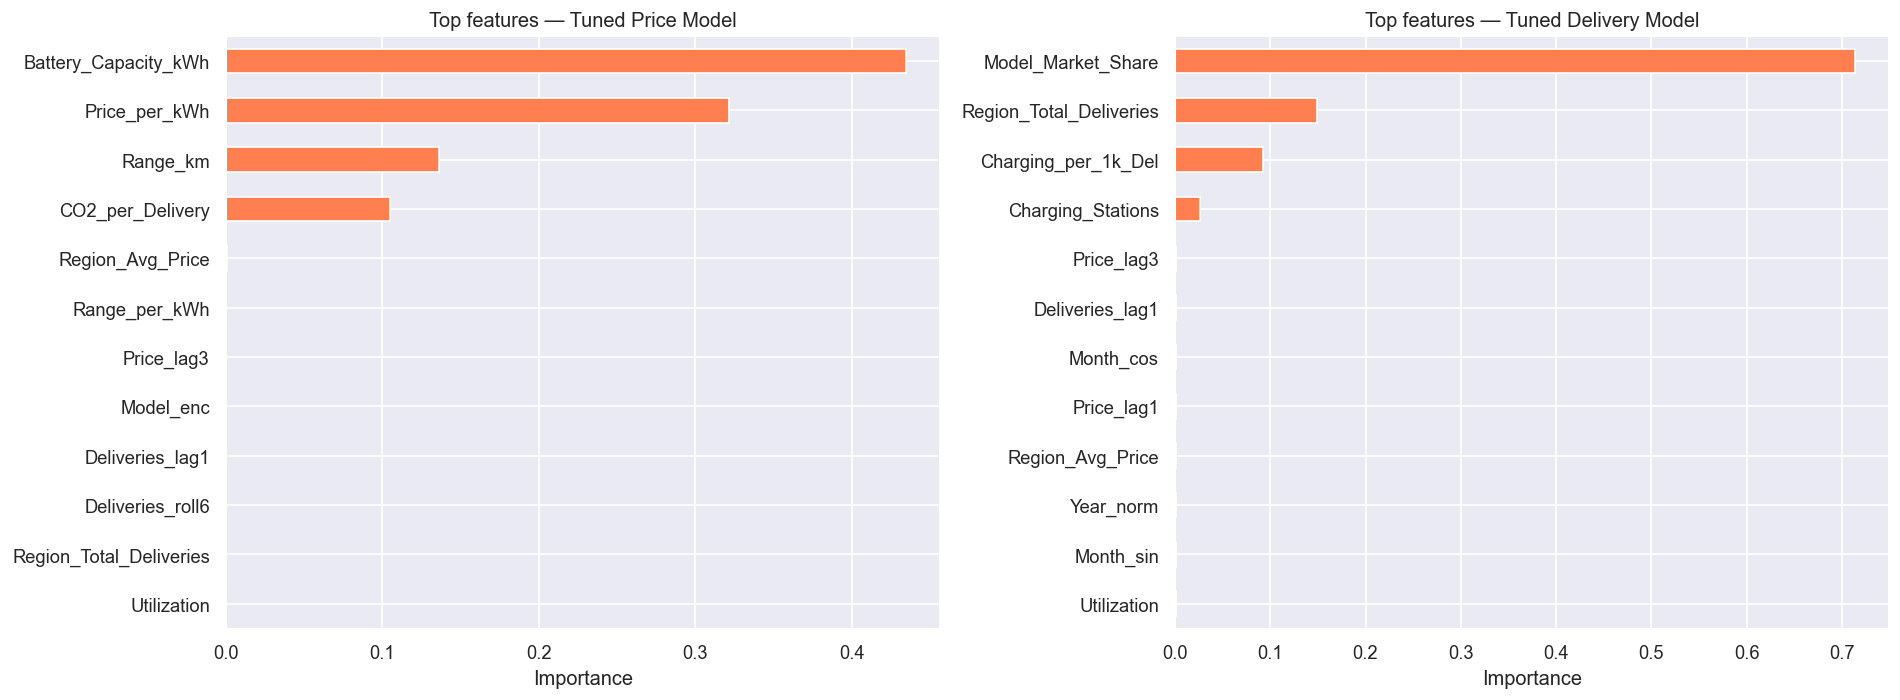

In [44]:
# ── 6.6  Feature importance — tuned models ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, estimator, title in zip(
    axes,
    [search_price.best_estimator_, search_del.best_estimator_],
    ["Top features — Tuned Price Model", "Top features — Tuned Delivery Model"]
):
    imp = pd.Series(estimator.feature_importances_, index=feature_cols)
    imp.sort_values().tail(12).plot(kind="barh", ax=ax, color="coral")
    ax.set_title(title)
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

In [45]:
# ── 6.7  Save best models for Step 7 ─────────────────────────
best_price_model    = search_price.best_estimator_
best_delivery_model = search_del.best_estimator_

print("✅ Best tuned models saved as:")
print("   best_price_model    → use for price prediction")
print("   best_delivery_model → use for delivery prediction")

✅ Best tuned models saved as:
   best_price_model    → use for price prediction
   best_delivery_model → use for delivery prediction


In [47]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 7.5 MB/s eta 0:00:02
   ---- ----------------------------------- 1.3/12.1 MB 3.5 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/12.1 MB 4.1 MB/s eta 0:00:03
   ----------- ---------------------------- 3.4/12.1 MB 4.5 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/12.1 MB 4.7 MB/s eta 0:00:02
   ------------------- -------------------- 5.8/12.1 MB 5.0 MB/s eta 0:00:02
   --------------------- ------------------ 6.6/12.1 MB 4.9 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/12.1 MB 4.8 MB/s eta 0:00:01
   ----------------------------- ---------- 8.9/12.1 MB 5.0 MB/s eta 0:00:01
   --------------------------------- ------ 10.2/12.1 MB 5.1 MB/s eta 0:00:01
   ------------------------------------- -- 11.3/12.1 MB 5.1 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 5.0 MB/s eta 0:00:00
   

In [49]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [50]:
# ── 7.1  Aggregate to monthly time series ────────────────────
# Use original df (before lag-dropping) for full 2640 rows
ts_del   = df.groupby("Date")["Estimated_Deliveries"].sum().reset_index()
ts_price = df.groupby("Date")["Avg_Price_USD"].mean().reset_index()

ts_del   = ts_del.set_index("Date").asfreq("MS")    # MS = month start
ts_price = ts_price.set_index("Date").asfreq("MS")

print("Delivery series shape:", ts_del.shape)
print("Price series shape:   ", ts_price.shape)
print(ts_del.tail(3))

Delivery series shape: (132, 1)
Price series shape:    (132, 1)
            Estimated_Deliveries
Date                            
2025-10-01                178964
2025-11-01                197146
2025-12-01                209391


In [51]:
# ── 7.2  Stationarity check (ADF test) ───────────────────────
def adf_test(series, name):
    result = adfuller(series.dropna())
    p = result[1]
    print(f"{name}: ADF stat={result[0]:.4f}, p-value={p:.4f} "
          f"→ {'✅ Stationary' if p < 0.05 else '⚠️ Non-stationary (needs differencing)'}")

adf_test(ts_del["Estimated_Deliveries"],  "Deliveries")
adf_test(ts_price["Avg_Price_USD"],       "Avg Price")

Deliveries: ADF stat=-8.8810, p-value=0.0000 → ✅ Stationary
Avg Price: ADF stat=-9.8870, p-value=0.0000 → ✅ Stationary


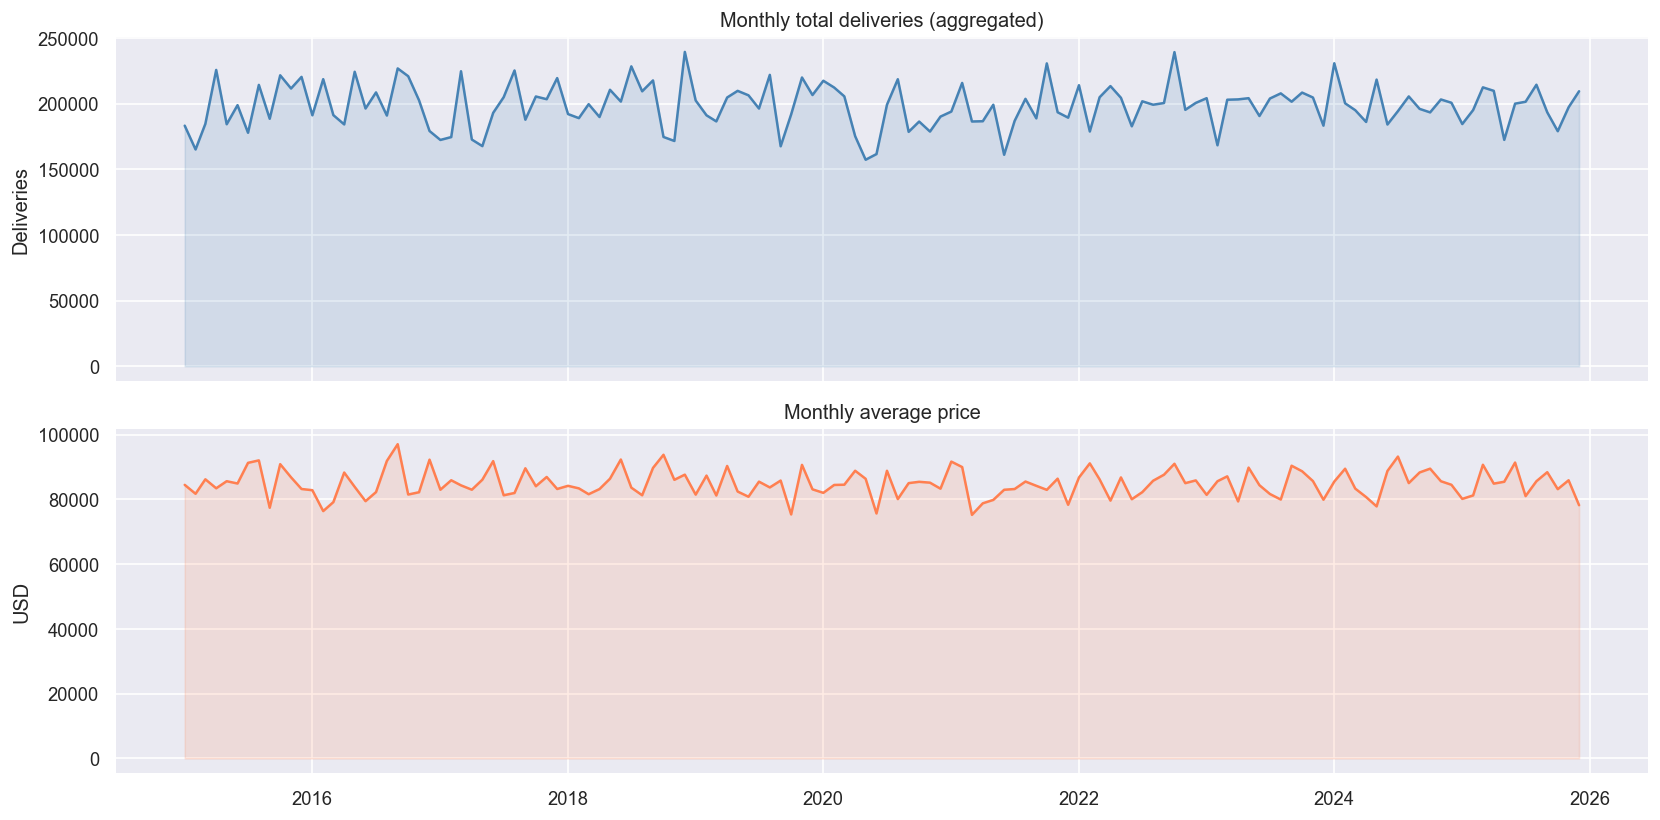

In [52]:
# ── 7.3  Plot the two series ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(ts_del.index, ts_del["Estimated_Deliveries"], color="steelblue", linewidth=1.5)
axes[0].fill_between(ts_del.index, ts_del["Estimated_Deliveries"], alpha=0.15, color="steelblue")
axes[0].set_title("Monthly total deliveries (aggregated)")
axes[0].set_ylabel("Deliveries")

axes[1].plot(ts_price.index, ts_price["Avg_Price_USD"], color="coral", linewidth=1.5)
axes[1].fill_between(ts_price.index, ts_price["Avg_Price_USD"], alpha=0.15, color="coral")
axes[1].set_title("Monthly average price")
axes[1].set_ylabel("USD")

plt.tight_layout()
plt.show()

In [53]:
# ── 7.4  Train/test split for time series (last 12 months = test)
FORECAST_MONTHS = 12

train_del   = ts_del.iloc[:-FORECAST_MONTHS]
test_del    = ts_del.iloc[-FORECAST_MONTHS:]

train_price = ts_price.iloc[:-FORECAST_MONTHS]
test_price  = ts_price.iloc[-FORECAST_MONTHS:]

print(f"Train: {train_del.index[0].date()} → {train_del.index[-1].date()}")
print(f"Test:  {test_del.index[0].date()}  → {test_del.index[-1].date()}")

Train: 2015-01-01 → 2024-12-01
Test:  2025-01-01  → 2025-12-01


In [54]:
# ── 7.5  SARIMA — Deliveries ──────────────────────────────────
# order=(p,d,q) seasonal_order=(P,D,Q,12)
# d=1 if ADF non-stationary, else 0
sarima_del = SARIMAX(
    train_del["Estimated_Deliveries"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_del_fit = sarima_del.fit(disp=False)
print(sarima_del_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:               Estimated_Deliveries   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -1061.796
Date:                            Fri, 29 May 2026   AIC                           2133.592
Time:                                    13:50:17   BIC                           2146.255
Sample:                                01-01-2015   HQIC                          2138.705
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         


In [55]:
# ── 7.6  SARIMA — Price ───────────────────────────────────────
sarima_price = SARIMAX(
    train_price["Avg_Price_USD"],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_price_fit = sarima_price.fit(disp=False)
print(sarima_price_fit.summary().tables[0])

                                     SARIMAX Results                                      
Dep. Variable:                      Avg_Price_USD   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -935.534
Date:                            Fri, 29 May 2026   AIC                           1881.068
Time:                                    13:50:28   BIC                           1893.731
Sample:                                01-01-2015   HQIC                          1886.181
                                     - 12-01-2024                                         
Covariance Type:                              opg                                         


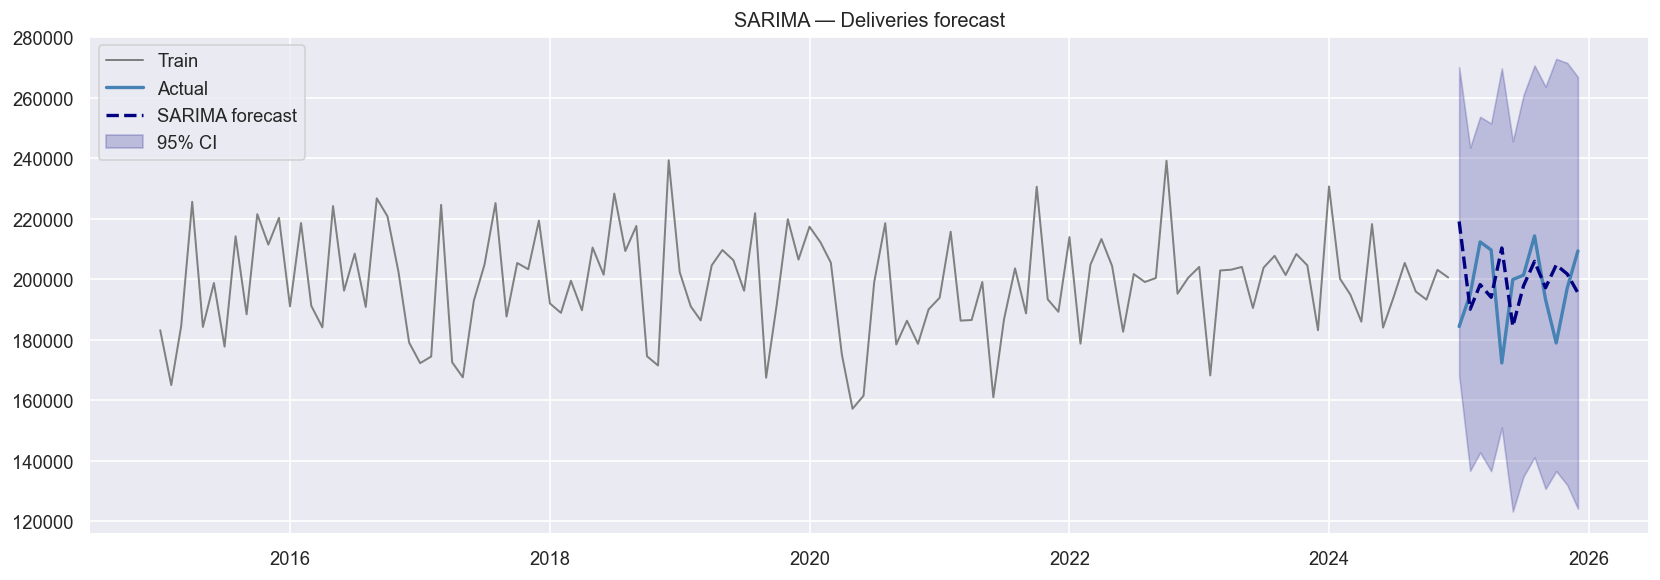

SARIMA MAPE (SARIMA — Deliveries forecast): 8.02%


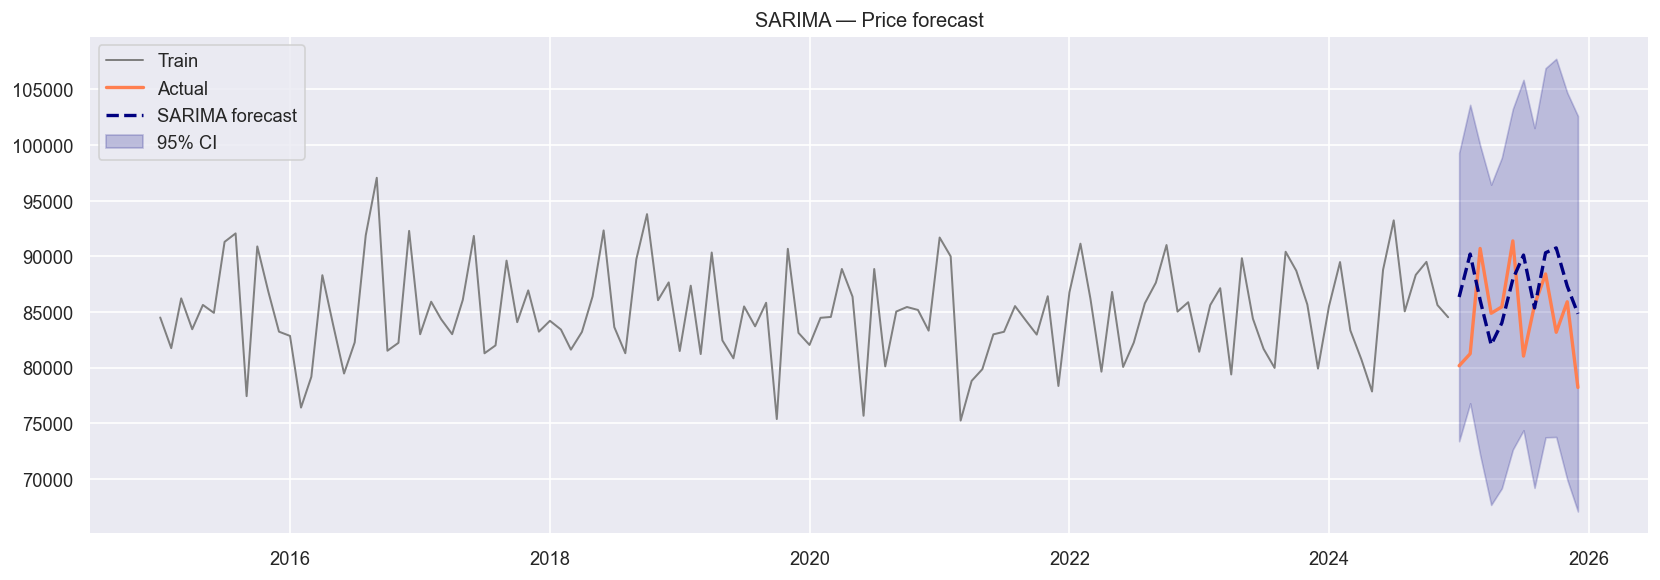

SARIMA MAPE (SARIMA — Price forecast): 5.46%


In [56]:
# ── 7.7  SARIMA forecast + plot ───────────────────────────────
def plot_sarima(fit, train, test, title, color):
    forecast = fit.get_forecast(steps=FORECAST_MONTHS)
    pred_mean = forecast.predicted_mean
    conf_int  = forecast.conf_int()

    plt.figure(figsize=(14, 5))
    plt.plot(train.index, train.iloc[:, 0], label="Train", color="gray", linewidth=1.2)
    plt.plot(test.index,  test.iloc[:, 0],  label="Actual", color=color, linewidth=2)
    plt.plot(pred_mean.index, pred_mean,    label="SARIMA forecast", color="navy",
             linewidth=2, linestyle="--")
    plt.fill_between(conf_int.index,
                     conf_int.iloc[:, 0], conf_int.iloc[:, 1],
                     alpha=0.2, color="navy", label="95% CI")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # MAPE
    mape = np.mean(np.abs((test.iloc[:, 0].values - pred_mean.values)
                          / test.iloc[:, 0].values)) * 100
    print(f"SARIMA MAPE ({title}): {mape:.2f}%")
    return pred_mean

sarima_del_forecast   = plot_sarima(sarima_del_fit,   train_del,   test_del,
                                    "SARIMA — Deliveries forecast", "steelblue")
sarima_price_forecast = plot_sarima(sarima_price_fit, train_price, test_price,
                                    "SARIMA — Price forecast", "coral")

13:50:42 - cmdstanpy - INFO - Chain [1] start processing
13:50:43 - cmdstanpy - INFO - Chain [1] done processing


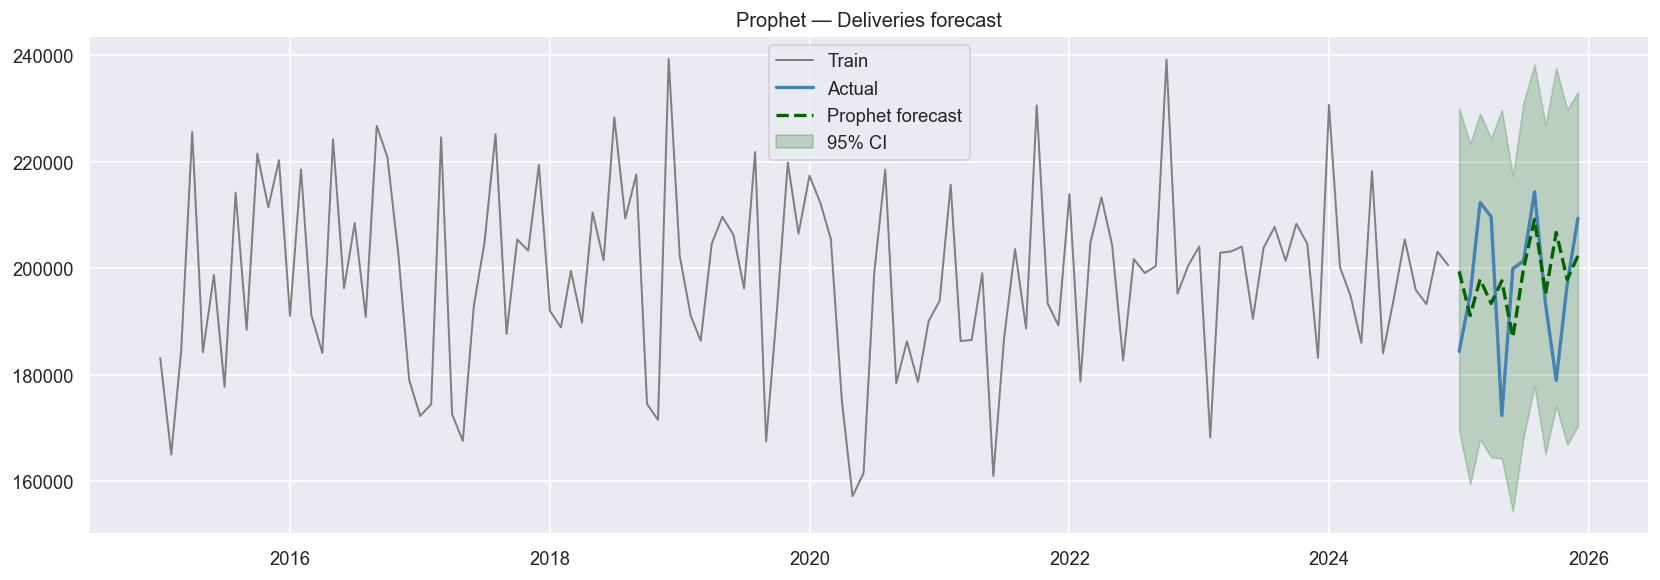

Prophet MAPE (Prophet — Deliveries forecast): 5.77%


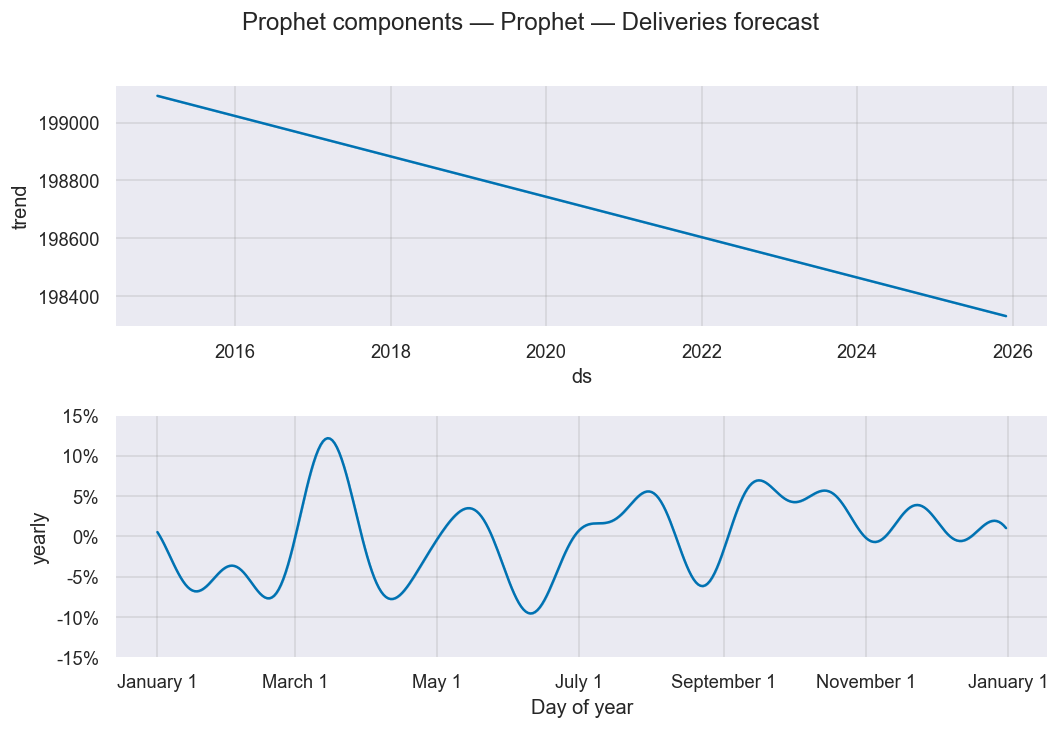

13:50:45 - cmdstanpy - INFO - Chain [1] start processing
13:50:45 - cmdstanpy - INFO - Chain [1] done processing


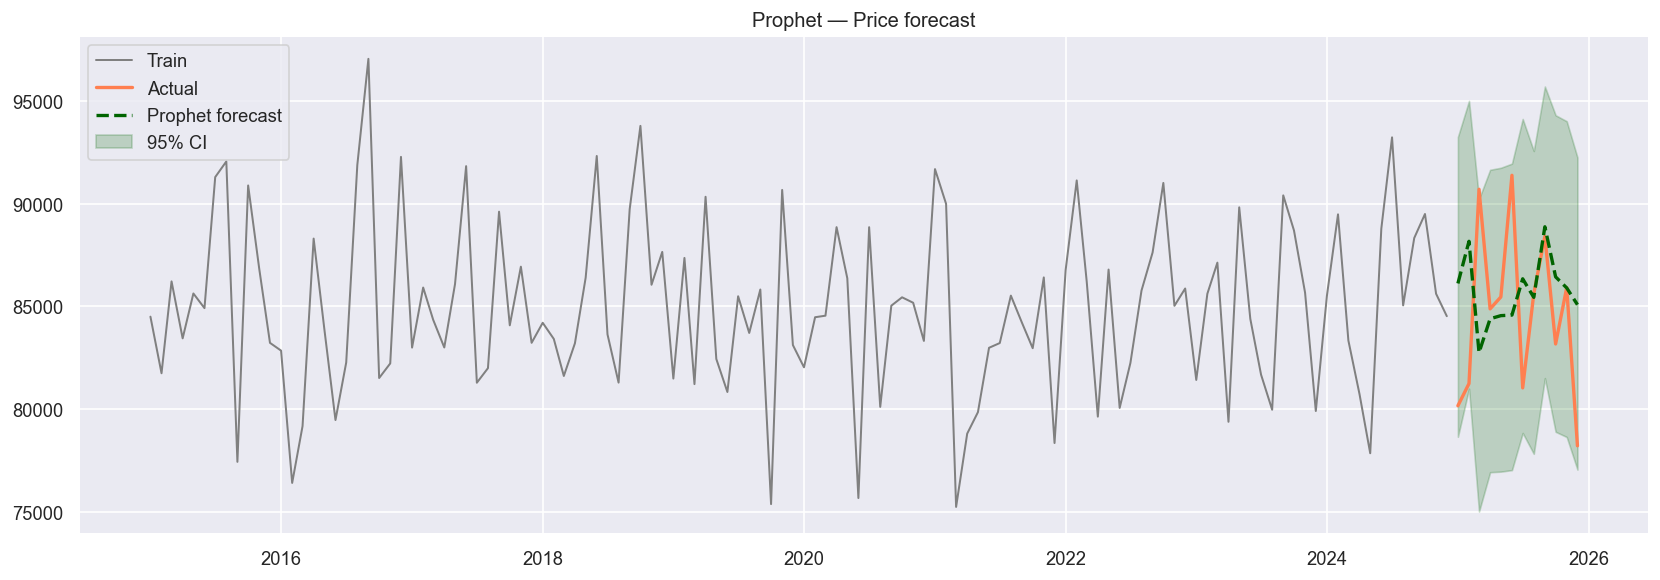

Prophet MAPE (Prophet — Price forecast): 4.49%


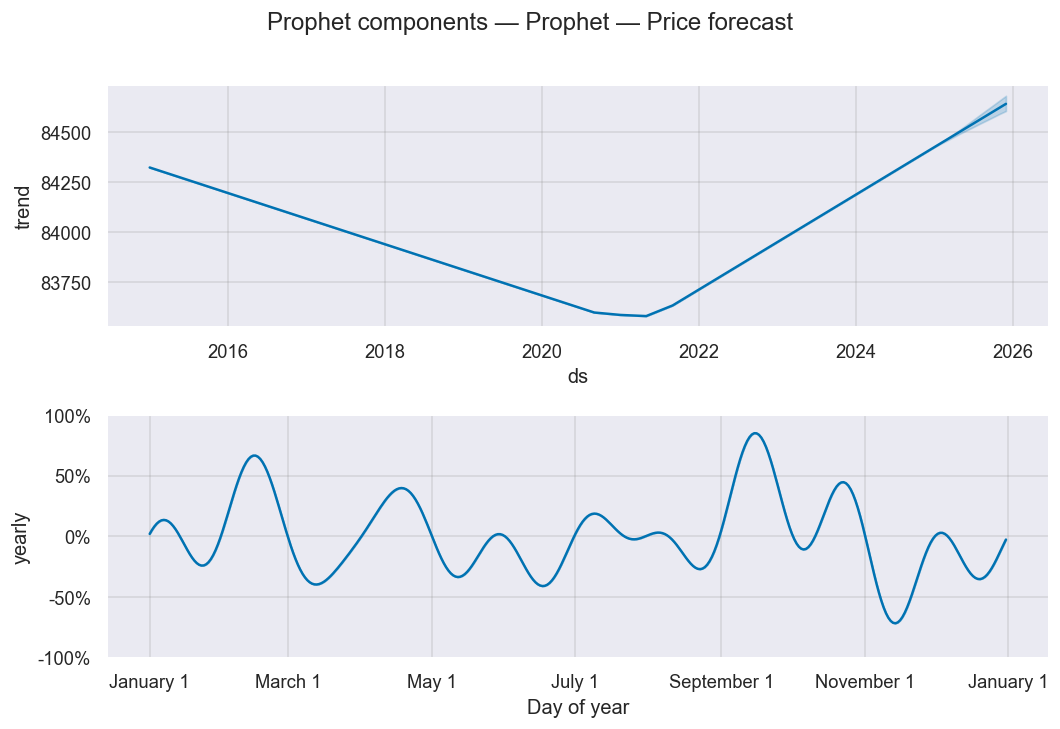

In [57]:
# ── 7.8  Prophet — Deliveries ─────────────────────────────────
def run_prophet(train, test, col, title, color):
    # Prophet needs columns: ds (date), y (value)
    prophet_df = train.reset_index().rename(columns={"Date": "ds", col: "y"})

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode="multiplicative",  # good for data with cycles
        interval_width=0.95
    )
    m.fit(prophet_df)

    future   = m.make_future_dataframe(periods=FORECAST_MONTHS, freq="MS")
    forecast = m.predict(future)

    # Plot
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(train.index, train[col], label="Train", color="gray", linewidth=1.2)
    ax.plot(test.index,  test[col],  label="Actual", color=color, linewidth=2)

    fc_test = forecast.set_index("ds").loc[test.index]
    ax.plot(fc_test.index, fc_test["yhat"],       label="Prophet forecast",
            color="darkgreen", linewidth=2, linestyle="--")
    ax.fill_between(fc_test.index,
                    fc_test["yhat_lower"], fc_test["yhat_upper"],
                    alpha=0.2, color="darkgreen", label="95% CI")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

    mape = np.mean(np.abs((test[col].values - fc_test["yhat"].values)
                          / test[col].values)) * 100
    print(f"Prophet MAPE ({title}): {mape:.2f}%")

    # Component plot
    m.plot_components(forecast)
    plt.suptitle(f"Prophet components — {title}", y=1.01)
    plt.tight_layout()
    plt.show()

run_prophet(train_del,   test_del,   "Estimated_Deliveries",
            "Prophet — Deliveries forecast", "steelblue")
run_prophet(train_price, test_price, "Avg_Price_USD",
            "Prophet — Price forecast", "coral")

In [59]:
# ── Recalculate all MAPE values directly ─────────────────────
from prophet import Prophet
import numpy as np

# SARIMA MAPEs
sarima_del_pred   = sarima_del_fit.get_forecast(steps=FORECAST_MONTHS).predicted_mean
sarima_price_pred = sarima_price_fit.get_forecast(steps=FORECAST_MONTHS).predicted_mean

mape_sarima_del   = np.mean(np.abs((test_del["Estimated_Deliveries"].values
                                    - sarima_del_pred.values)
                                   / test_del["Estimated_Deliveries"].values)) * 100

mape_sarima_price = np.mean(np.abs((test_price["Avg_Price_USD"].values
                                    - sarima_price_pred.values)
                                   / test_price["Avg_Price_USD"].values)) * 100

# Prophet MAPEs
def get_prophet_mape(train, test, col):
    prophet_df = train.reset_index().rename(columns={"Date": "ds", col: "y"})
    m = Prophet(yearly_seasonality=True, weekly_seasonality=False,
                daily_seasonality=False, seasonality_mode="multiplicative",
                interval_width=0.95)
    m.fit(prophet_df)
    future   = m.make_future_dataframe(periods=FORECAST_MONTHS, freq="MS")
    forecast = m.predict(future)
    fc_test  = forecast.set_index("ds").loc[test.index]
    mape = np.mean(np.abs((test[col].values - fc_test["yhat"].values)
                          / test[col].values)) * 100
    return mape

mape_prophet_del   = get_prophet_mape(train_del,   test_del,   "Estimated_Deliveries")
mape_prophet_price = get_prophet_mape(train_price, test_price, "Avg_Price_USD")

# Summary table
print("=" * 55)
print(f"{'Model':<12} {'Target':<25} {'MAPE':>8}")
print("=" * 55)
print(f"{'SARIMA':<12} {'Estimated_Deliveries':<25} {mape_sarima_del:>7.2f}%")
print(f"{'SARIMA':<12} {'Avg_Price_USD':<25} {mape_sarima_price:>7.2f}%")
print(f"{'Prophet':<12} {'Estimated_Deliveries':<25} {mape_prophet_del:>7.2f}%")
print(f"{'Prophet':<12} {'Avg_Price_USD':<25} {mape_prophet_price:>7.2f}%")
print("=" * 55)

# Best model recommendation
print("\n📌 Best model per target:")
print(f"  Deliveries: {'SARIMA' if mape_sarima_del < mape_prophet_del else 'Prophet'} "
      f"(MAPE {min(mape_sarima_del, mape_prophet_del):.2f}%)")
print(f"  Price:      {'SARIMA' if mape_sarima_price < mape_prophet_price else 'Prophet'} "
      f"(MAPE {min(mape_sarima_price, mape_prophet_price):.2f}%)")

13:51:28 - cmdstanpy - INFO - Chain [1] start processing
13:51:28 - cmdstanpy - INFO - Chain [1] done processing
13:51:28 - cmdstanpy - INFO - Chain [1] start processing
13:51:28 - cmdstanpy - INFO - Chain [1] done processing


Model        Target                        MAPE
SARIMA       Estimated_Deliveries         8.02%
SARIMA       Avg_Price_USD                5.46%
Prophet      Estimated_Deliveries         5.77%
Prophet      Avg_Price_USD                4.49%

📌 Best model per target:
  Deliveries: Prophet (MAPE 5.77%)
  Price:      Prophet (MAPE 4.49%)
